Drawdown, rolling Sharpe, and trade-level statistics.
Assumes `backtest_results` has been run; re-runs the backtest here to keep this notebook self-contained.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.loader import load_data
from src.pairs.selection import test_all_pairs
from src.strategy.backtest import BacktestParams, run_portfolio_backtest
from src.analysis.performance import compute_metrics_with_positions

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
prices, _ = load_data(config_path="../config/params.yaml")
pairs = test_all_pairs(prices, pvalue_threshold=0.05, top_n=20)

params = BacktestParams(
    entry_z=2.0, exit_z=0.5, stop_z=3.5,
    zscore_window=252, cost_bps=5.0, notional=1.0,
    formation=252, trading=63, step=21,
)

results     = run_portfolio_backtest(prices, pairs, params)
portfolio   = results["portfolio"]
pair_results = results["pairs"]

port = portfolio.dropna()
print(f"{len(pair_results)} pairs, {len(port)} trading days")

Dropped 2 tickers (insufficient history): {'DOW', 'WBA'}


20 pairs, 1491 trading days


Drawdown — underwater chart

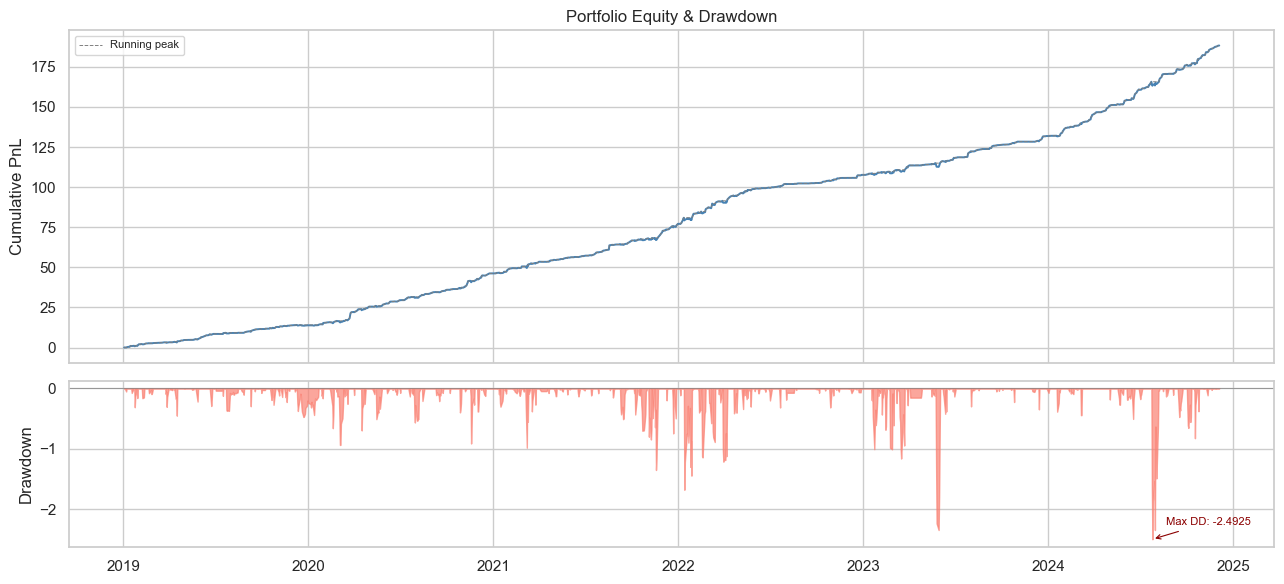

In [3]:
cum_pnl      = port["cumulative_pnl"]
running_peak = cum_pnl.cummax()
drawdown     = cum_pnl - running_peak  # always ≤ 0

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# equity
axes[0].plot(cum_pnl.index, cum_pnl.values, color="steelblue", linewidth=1.4)
axes[0].plot(running_peak.index, running_peak.values, color="grey",
             linewidth=0.7, linestyle="--", label="Running peak")
axes[0].set_ylabel("Cumulative PnL")
axes[0].set_title("Portfolio Equity & Drawdown")
axes[0].legend(fontsize=8)

# underwater
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color="salmon", alpha=0.7)
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

Rolling Sharpe — 6-month window (126 trading days)

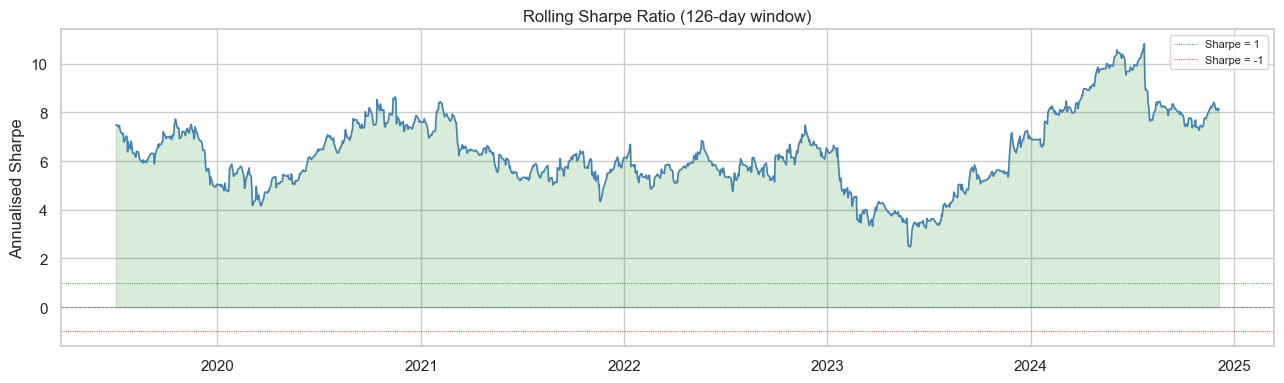

Fraction of rolling windows with positive Sharpe: 100.0%


In [4]:
WINDOW = 126  # ≈ 6 months
ANNUAL = 252

pnl = port["daily_pnl"]
rolling_mean = pnl.rolling(WINDOW).mean()
rolling_std  = pnl.rolling(WINDOW).std(ddof=1)
rolling_sharpe = rolling_mean / rolling_std * np.sqrt(ANNUAL)

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1.2, color="steelblue")
ax.axhline(0,   color="grey",   linewidth=0.6, linestyle="--")
ax.axhline(1,   color="green",  linewidth=0.6, linestyle=":", label="Sharpe = 1")
ax.axhline(-1,  color="red",    linewidth=0.6, linestyle=":", label="Sharpe = -1")

ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe > 0, alpha=0.15, color="green")
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe < 0, alpha=0.15, color="red")

ax.set_title(f"Rolling Sharpe Ratio ({WINDOW}-day window)")
ax.set_ylabel("Annualised Sharpe")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

pct_positive = (rolling_sharpe.dropna() > 0).mean()
print(f"Fraction of rolling windows with positive Sharpe: {pct_positive:.1%}")

Trade-level analysis: Extract individual completed trades (contiguous non-zero position runs) across all pairs.

In [5]:
def extract_trades(position: pd.Series, daily_pnl: pd.Series) -> pd.DataFrame:
    """
    Group consecutive non-zero position days into individual trades.

    A trade is a contiguous run of identical non-zero position values.
    PnL is summed over the run (transaction costs are already included in daily_pnl).
    """
    pos = position.fillna(0).astype(int)
    pnl = daily_pnl.reindex(pos.index).fillna(0)

    is_in_trade = pos != 0
    # New block whenever the in-trade state changes
    block = (is_in_trade != is_in_trade.shift(fill_value=False)).cumsum()
    block = block.where(is_in_trade)  # NaN on flat days

    records = []
    for _, grp_idx in pnl.groupby(block).groups.items():
        grp_pos = pos.loc[grp_idx]
        grp_pnl = pnl.loc[grp_idx]
        records.append({
            "entry_date":        grp_idx[0],
            "exit_date":         grp_idx[-1],
            "direction":         int(grp_pos.iloc[0]),
            "holding_period_days": len(grp_idx),
            "pnl":               grp_pnl.sum(),
        })

    return pd.DataFrame(records)


all_trades = pd.concat(
    [extract_trades(df["position"], df["daily_pnl"]).assign(pair=name)
     for name, df in pair_results.items()],
    ignore_index=True,
)

print(f"{len(all_trades)} trades across {len(pair_results)} pairs")
print(f"  Long:  {(all_trades['direction'] == 1).sum()}")
print(f"  Short: {(all_trades['direction'] == -1).sum()}")
all_trades.describe()

880 trades across 20 pairs
  Long:  423
  Short: 457


,entry_date,exit_date,direction,holding_period_days,pnl
count,880,880,880.000000,880.000000,880.000000
mean,2022-01-31 09:11:27.272727,2022-02-06 14:10:54.545454,-0.038636,5.229545,3.060683
min,2019-01-03 00:00:00,2019-01-04 00:00:00,-1.000000,1.000000,-12.977645
25%,2020-06-10 18:00:00,2020-06-30 12:00:00,-1.000000,2.000000,-0.000500
50%,2022-01-19 12:00:00,2022-01-24 00:00:00,-1.000000,3.000000,1.517878
75%,2023-08-25 06:00:00,2023-08-26 06:00:00,1.000000,7.000000,4.785346
max,2024-12-03 00:00:00,2024-12-04 00:00:00,1.000000,74.000000,25.186590
std,NaN,NaN,0.999822,5.554532,4.259766


Trade PnL distribution and holding period

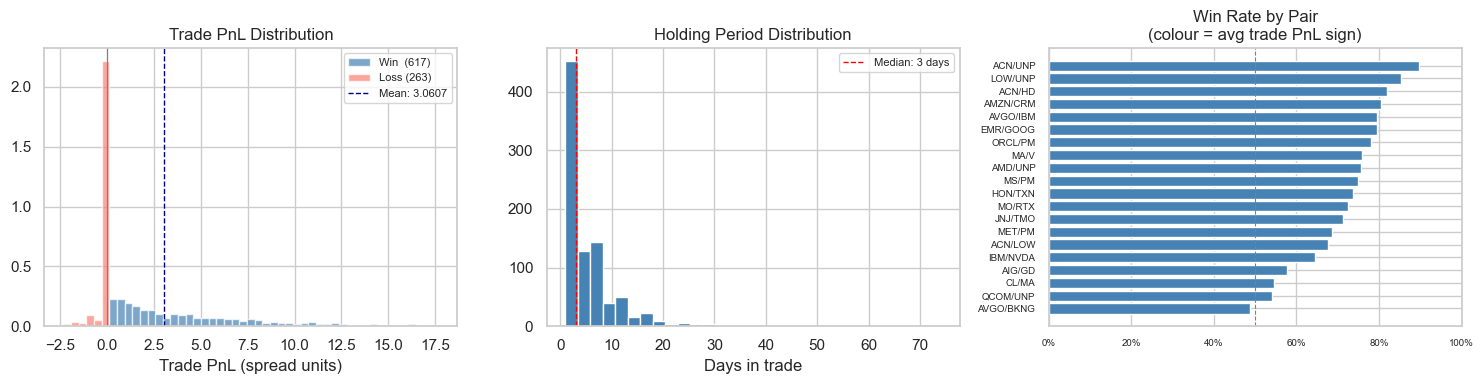

Overall win rate:     70.1%
Avg winning trade:   4.4987
Avg losing trade:    -0.3128
Profit factor:       14.38


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Trade PnL histogram ---
ax = axes[0]
wins   = all_trades[all_trades["pnl"] > 0]["pnl"]
losses = all_trades[all_trades["pnl"] < 0]["pnl"]
bins   = np.linspace(all_trades["pnl"].quantile(0.01),
                     all_trades["pnl"].quantile(0.99), 50)

ax.hist(wins,   bins=bins, color="steelblue", alpha=0.7, label=f"Win  ({len(wins)})",   density=True)
ax.hist(losses, bins=bins, color="salmon",    alpha=0.7, label=f"Loss ({len(losses)})", density=True)
ax.axvline(0, color="grey", linewidth=0.8)
ax.axvline(all_trades["pnl"].mean(), color="navy", linewidth=1.0,
           linestyle="--", label=f"Mean: {all_trades['pnl'].mean():.4f}")
ax.set_title("Trade PnL Distribution")
ax.set_xlabel("Trade PnL (spread units)")
ax.legend(fontsize=8)

# --- Holding period histogram ---
ax = axes[1]
ax.hist(all_trades["holding_period_days"], bins=30, color="steelblue", edgecolor="white")
median_hp = all_trades["holding_period_days"].median()
ax.axvline(median_hp, color="red", linewidth=1.0, linestyle="--",
           label=f"Median: {median_hp:.0f} days")
ax.set_title("Holding Period Distribution")
ax.set_xlabel("Days in trade")
ax.legend(fontsize=8)

# --- Win rate and avg PnL per pair ---
ax = axes[2]
pair_stats = (
    all_trades.groupby("pair")
    .apply(lambda g: pd.Series({
        "win_rate": (g["pnl"] > 0).mean(),
        "avg_pnl":  g["pnl"].mean(),
        "n_trades": len(g),
    }), include_groups=False)
    .sort_values("win_rate")
)
colors = ["steelblue" if r > 0 else "salmon" for r in pair_stats["avg_pnl"]]
bars = ax.barh(pair_stats.index, pair_stats["win_rate"], color=colors)
ax.axvline(0.5, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Win Rate by Pair\n(colour = avg trade PnL sign)")
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

overall_win_rate = (all_trades["pnl"] > 0).mean()
avg_win  = wins.mean()   if len(wins)   else 0
avg_loss = losses.mean() if len(losses) else 0
print(f"Overall win rate:     {overall_win_rate:.1%}")
print(f"Avg winning trade:   {avg_win:.4f}")
print(f"Avg losing trade:    {avg_loss:.4f}")
if avg_loss != 0:
    print(f"Profit factor:       {abs(avg_win / avg_loss):.2f}")